Dataset Saved Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8947 - loss: 0.6578 - val_accuracy: 1.0000 - val_loss: 0.6726
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9474 - loss: 0.6446 - val_accuracy: 0.8000 - val_loss: 0.6689
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9474 - loss: 0.6331 - val_accuracy: 0.8000 - val_loss: 0.6648
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9474 - loss: 0.6215 - val_accuracy: 0.8000 - val_loss: 0.6607
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8947 - loss: 0.6121 - val_accuracy: 0.8000 - val_loss: 0.6558
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8947 - loss: 0.6014 - val_accuracy: 0.8000 - val_loss: 0.6514
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8947 - loss: 0.5931 - val_accuracy: 0.8000 - val_loss: 0.6467
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8947 - loss: 0.5822 - val_accuracy: 0.8000 - val_loss: 0.6425


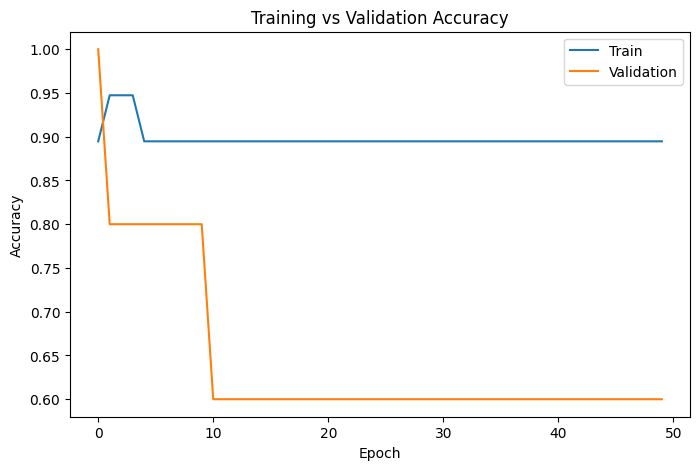

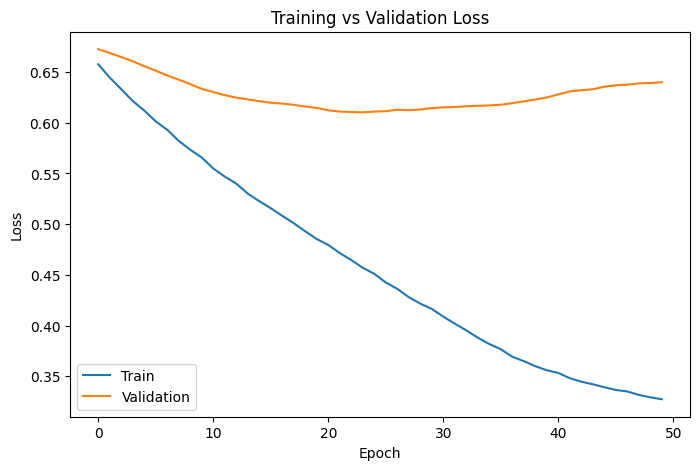

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.6061

ANN Accuracy = 0.5
Random Forest Accuracy = 1.0

Model Comparison
           Model  Accuracy
0            ANN       0.5
1  Random Forest       1.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All Files Ready & Downloaded


In [18]:
# ==========================
# TASK 8 - Neural Network Basics with Keras
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================
# Create CoreTech Dataset
# ==========================

data = {
    'Client_ID': range(1,31),

    'Service': [
        'Web Development','Mobile App','AI Solution','Web Development','Cloud Service',
        'AI Solution','Mobile App','Cloud Service','Web Development','AI Solution',
        'Mobile App','Cloud Service','Web Development','AI Solution','Mobile App',
        'Cloud Service','Web Development','AI Solution','Mobile App','Cloud Service',
        'Web Development','AI Solution','Mobile App','Cloud Service','Web Development',
        'AI Solution','Mobile App','Cloud Service','Web Development','AI Solution'
    ],

    'Budget': [
        5000,7000,12000,4500,10000,
        13000,7500,9000,6000,14000,
        7200,9500,5500,12500,8000,
        9200,6200,13500,7800,9800,
        5800,12800,7900,9400,6100,
        13800,8100,9600,5900,14500
    ],

    'Duration': [
        30,45,60,25,50,
        65,40,55,35,70,
        42,52,32,63,43,
        53,34,66,44,54,
        31,61,41,51,33,
        68,46,56,29,72
    ],

    'Satisfaction': [
        1,1,1,0,1,
        1,1,0,1,1,
        1,0,1,1,1,
        0,1,1,1,0,
        1,1,1,0,1,
        1,1,0,1,1
    ]
}

df = pd.DataFrame(data)

# Save Dataset
df.to_csv("coretech_clients.csv", index=False)

print("Dataset Saved Successfully")

# ==========================
# Data Preprocessing
# ==========================

encoder = LabelEncoder()
df['Service'] = encoder.fit_transform(df['Service'])

X = df[['Service','Budget','Duration']]
y = df['Satisfaction']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# ==========================
# ANN Model
# ==========================

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(3,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=4,
    verbose=1
)

# ==========================
# Accuracy Graph
# ==========================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.savefig("accuracy_curve.png")
plt.show()

# ==========================
# Loss Graph
# ==========================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])
plt.savefig("loss_curve.png")
plt.show()

# ==========================
# ANN Evaluation
# ==========================

loss, ann_accuracy = model.evaluate(X_test,y_test)

print("\nANN Accuracy =", ann_accuracy)

# ==========================
# Random Forest Comparison
# ==========================

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy =", rf_accuracy)

comparison = pd.DataFrame({
    'Model':['ANN','Random Forest'],
    'Accuracy':[ann_accuracy, rf_accuracy]
})

print("\nModel Comparison")
print(comparison)

comparison.to_csv("comparison_results.csv", index=False)

# ==========================
# Auto Download Files
# ==========================

from google.colab import files

files.download("coretech_clients.csv")
files.download("accuracy_curve.png")
files.download("loss_curve.png")
files.download("comparison_results.csv")

print("\nAll Files Ready & Downloaded")